Validation fiber delay
----------------------------
Validation of the fiber delay functionality and providing insight on if the delay is significant or can be discarded.

In [57]:
import yaml
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from plotter import plotter
from utils import calculate_psd_per_symbol
from wireless_channel.waveforms import Waveform
from sub_THz_stripe.radiostripe.radiostripe import RadioStripe
from sub_THz_stripe.radio_unit.radio_unit import RadioUnit
from wireless_channel.subTHz_channel import Channel
from sub_THz_stripe.central_unit.central_unit import CentralUnit

In [ ]:
# Read out the config file.
config_file = "examples/stripe_ul/delay_config.yml"
with open(config_file, "r", encoding="utf8") as file:
    config = yaml.safe_load(file)

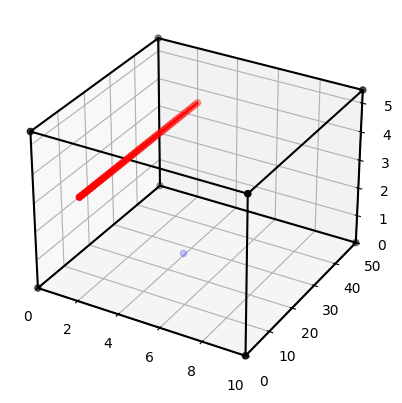

In [59]:
# Plot the room with the strip in it.
plotter.plot_room(config)

In [60]:
# Construct the waveform class based on the loaded configuration.
waveform_config = config["waveform_config"]
freq_band_config = config["sub_thz"]
wf = Waveform.from_config(waveform_config, freq_band_config)

In [61]:
# Build the RadioStripe object based on the configuration.
component_config = config["component_config"]
stripe_cfg = config["radio_stripes"][0]
rs = RadioStripe.from_config_locations(stripe_cfg, component_config, wf)

In [62]:
# Generate an CP-OFDM waveform in the time domain.
bits = wf.generate_bits()
qam = wf.qam_modulate()
ofdm_time = wf.ofdm_modulate()  # shape: nr_ofdm_symb x (fftsize + cp length)

In [63]:
# The UE has the same hardware as a central unit.
ue = CentralUnit()  # todo are these configs loadable?
ofdm_time_after_ue = ue.run(ofdm_time)  # shape: nr_ofdm_symbols x (fft_size + cp length)

# The UE position doesn't matter. We use the debug channel so the channel is all 1s anyhow.
ue_pos = config["ue_positions"][0]

# A single radio unit is used to represent the transmit stage of the ue.
ue_ru = RadioUnit(ue_pos["x"], ue_pos["y"], ue_pos["z"], wf)
# Transmit the data towards the stripe.
shifts = [0, 0, 0, 0]
iq_data_tx, imdata = ue_ru.transmit(ofdm_time_after_ue, shifts)

In [64]:
# Construct the wireless channel. Use a debugging channel with all 1s.
channel = Channel.from_sionna(ue_pos)
channel.Nr_stripes = 1
channel.Nr_rus = 49
x = list(range(49)) * len(channel.csi.RU_idx)
channel.csi['RU_idx'] = xr.DataArray(data=x)
channel.csi["channel"] = xr.ones_like(channel.csi["channel"])

# Transmit the data over the channel and get the data at all the radio units.
iq_data_rus = channel.transmit_ul(iq_data_tx, wf)

In [65]:
# Use a unit 10m away from the CU to verify the delay significance.
rs.active_unit = 20

# Receive the data on a single radio unit and make it run over the stripe. Do this twice with and without delay.
phase_shifts = [0, 0, 0, 0]
iq_out, imdata = rs.receive(iq_data_rus[0], phase_shifts, delay=False)
iq_out_delayed, imdata_delayed = rs.receive(iq_data_rus[0], phase_shifts, delay=True)

# Put all the symbols in one big array.
iq_out = np.squeeze(iq_out)
iq_out_delayed = np.squeeze(iq_out_delayed)

False


Text(0, 0.5, 'Amplitude')

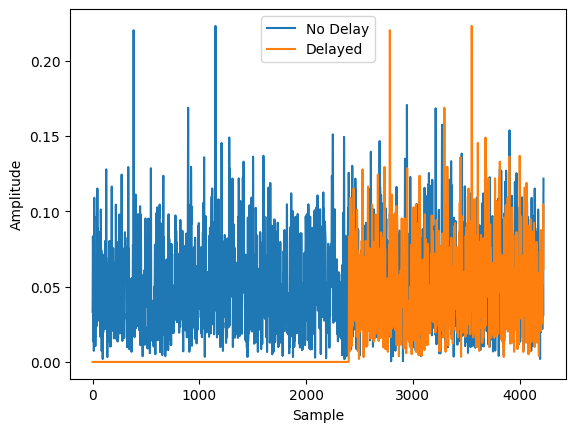

In [66]:
# Make time plots for comparison.
fig, ax = plt.subplots()

print(np.allclose(iq_out, iq_out_delayed))

ax.plot(np.arange(len(iq_out)), np.abs(iq_out), label="No Delay")
ax.plot(np.arange(len(iq_out_delayed)), np.abs(iq_out_delayed), label="Delayed")
ax.legend()

ax.set_xlabel("Sample")
ax.set_ylabel("Amplitude")

False


Text(0, 0.5, 'Power Spectral Density (dB/Hz)')

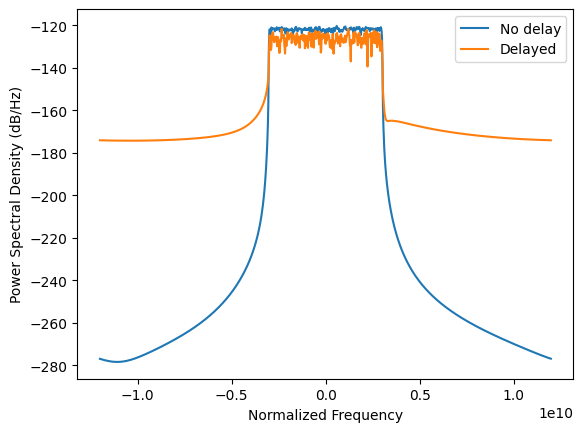

In [67]:
# Plot the data arriving at the central unit.
fig, ax = plt.subplots()

# Calculate the PSD.
freq, psd = calculate_psd_per_symbol(iq_out, wf.fs)
freq_delayed, psd_delayed = calculate_psd_per_symbol(iq_out_delayed, wf.fs)

print(np.allclose(psd, psd_delayed))

ax.plot(freq, psd, label="No delay")
ax.plot(freq_delayed, psd_delayed, label="Delayed")
ax.legend()

ax.set_xlabel("Normalized Frequency")
ax.set_ylabel("Power Spectral Density (dB/Hz)")